# Dataset Cleaning
After my Initial Analysis of the dataset I believe I have a solid understanding of what the data entails. Now I am going to perform a data cleaning with the inspection I have done to prepare it for the final EDA process of analyzing the data with different charts. 

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

from scipy import stats

In [2]:
df_e = pd.read_csv('../datasets/ENB2012_data.csv')

Since the names of all of the columns so far have been written very vaugly I am going to redeclare the names of each variable so that it is easier to understand the data. 

In [3]:
column_mapping = {
    'X1': 'Relative Compactness',
    'X2': 'Surface Area',
    'X3': 'Wall Area',
    'X4': 'Roof Area',
    'X5': 'Overall Height',
    'X6': 'Orientation',
    'X7': 'Glazing Area',
    'X8': 'Glazing Area Distribution',
    'Y1': 'Heating Load',
    'Y2': 'Cooling Load'
}

df_e = df_e.rename(columns = column_mapping)
df_e.head()


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


dataframe shape

In [4]:
print("Shape: ", df_e.shape)

Shape:  (768, 10)


Check if any data needs data types fixed. 

In [6]:
print("These are the data types for the dataset columns")
display(df_e.dtypes)

These are the data types for the dataset columns


Relative Compactness         float64
Surface Area                 float64
Wall Area                    float64
Roof Area                    float64
Overall Height               float64
Orientation                    int64
Glazing Area                 float64
Glazing Area Distribution      int64
Heating Load                 float64
Cooling Load                 float64
dtype: object

Here I am checking all of the columns once again to just to make sure that all of them are relevant.

In [9]:
print(df_e.columns.tolist())


['Relative Compactness', 'Surface Area', 'Wall Area', 'Roof Area', 'Overall Height', 'Orientation', 'Glazing Area', 'Glazing Area Distribution', 'Heating Load', 'Cooling Load']


I am going to fix any incorrect data types that may be found. 

In [11]:
df_e['Orientation'] = df_e['Orientation'].astype('category')
df_e['Glazing Area Distribution'] = df_e['Glazing Area Distribution'].astype('category')
print(df_e.dtypes)


Relative Compactness          float64
Surface Area                  float64
Wall Area                     float64
Roof Area                     float64
Overall Height                float64
Orientation                  category
Glazing Area                  float64
Glazing Area Distribution    category
Heating Load                  float64
Cooling Load                  float64
dtype: object


check for missing values

In [ ]:
df_e.isnull().sum()

Check for any duplicate rows 

In [19]:
print(f'Duplicate rows: {df_e.duplicated().sum()}')

Duplicate rows: 0


Check for any obvious data entry errors 

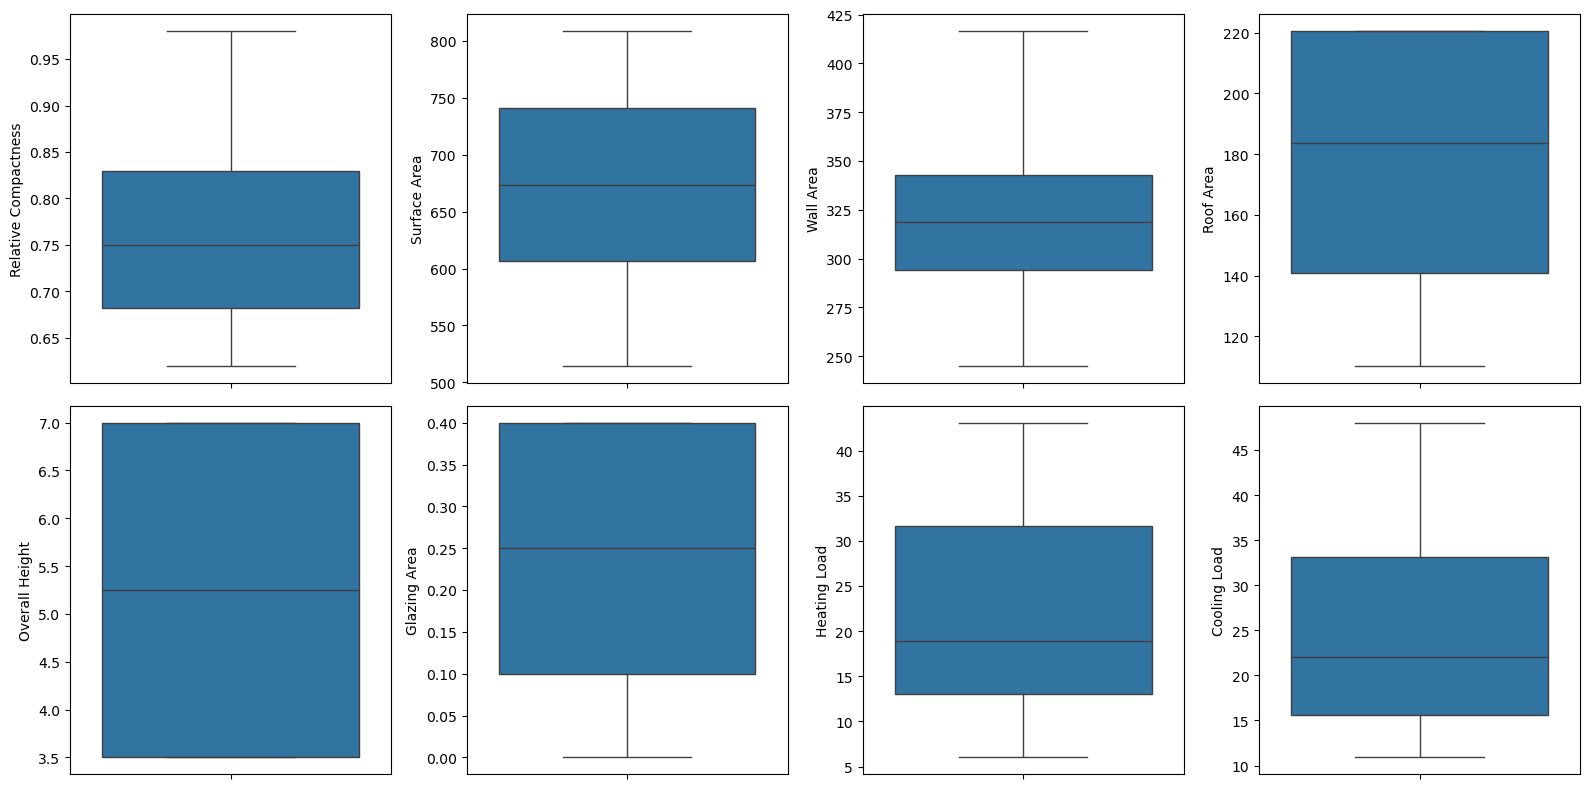

In [22]:
fig, axes = plt.subplots(2 ,4, figsize = (16, 8))
axes = axes.flatten()
for i, col in enumerate(df_e.select_dtypes(include='float64').columns):
    sns.boxplot(data = df_e, y = col, ax = axes [i])
plt.tight_layout()
plt.show()

In [4]:
df_e.to_csv('../datasets/ENB2012_clean.csv', index = False)
print('Clean dataset saved')

Clean dataset saved
